## Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from raccoon import WiggleCleaner
from raccoon.util import Util

## Load data

The example data used in this demo is a clipped version of the data from [Perna et al. (2023)](https://www.aanda.org/articles/aa/full_html/2023/11/aa46649-23/aa46649-23.html).

In [2]:
datacube_file = "./example_data.fits"
data_cube, header = fits.getdata(datacube_file, header=True)
# Attention: default pipeline-reduced datacubes will have the noise layer at ext=2
noise_cube = fits.getdata(datacube_file, ext=1)

wavelengths = (header["CRVAL3"] + header["CDELT3"] * np.arange(header["NAXIS3"])) * 1e4

data_cube.shape, noise_cube.shape, wavelengths.shape

((1363, 33, 33), (1363, 33, 33), (1363,))

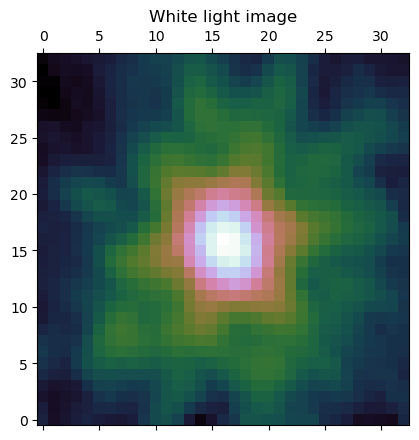

In [3]:
plt.matshow(np.log10(np.nansum(data_cube, axis=0)), cmap="cubehelix", origin="lower")
plt.title("White light image")
plt.show()

In [4]:
quasar_x, quasar_y = 16, 16

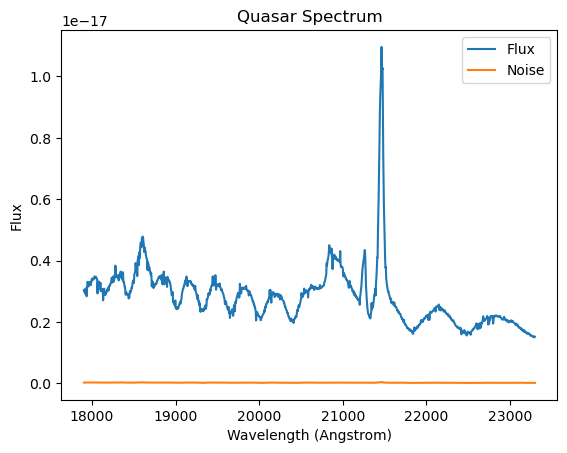

In [5]:
plt.plot(wavelengths, data_cube[:, quasar_y, quasar_x], label="Flux")
plt.plot(wavelengths, noise_cube[:, quasar_y, quasar_x], label="Noise")
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("Quasar Spectrum")
plt.legend()
plt.show()

### Identify lines to make gaps in the fitting

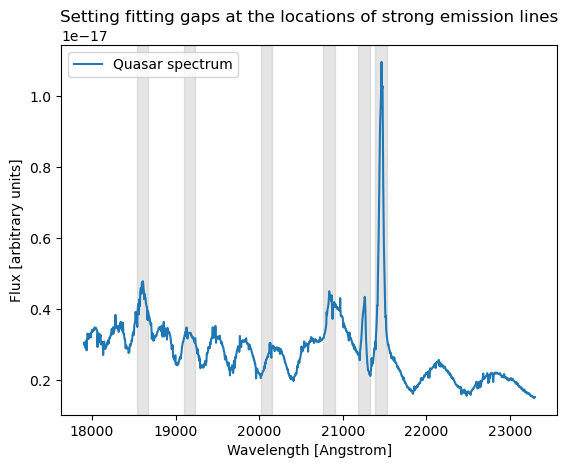

In [6]:
gaps = [
    [18541.43, 18665.54],
    [19099.23, 19227.08],
    [20016.21, 20150.19],
    [20766.39, 20905.39],
    [21183.25, 21325.04],
    [21388.00, 21531.16],
]

plt.plot(wavelengths, data_cube[:, quasar_y, quasar_x], label="Quasar spectrum")

for gap in gaps:
    plt.axvspan(gap[0], gap[1], color="grey", alpha=0.2)

plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Flux [arbitrary units]")
plt.legend()
plt.title("Setting fitting gaps at the locations of strong emission lines")
plt.show()

### Create the `WiggleCleaner` object

In [7]:
wcleaner = WiggleCleaner(
    wavelengths,
    data_cube,
    noise_cube,
    # gaps=gaps,
    continuum_diff_polynomial_order=2,
    symmetric_sharpening=True,  # Set to False if you want to disable symmetric sharpening
    asymmetric_sharpening=True,  # Set to False if you want to disable asymmetric sharpening
)

## Check for optimal aperture and annulus size 

Here, we experiemnt with optimal aperture and annulus sizes. We aim to find the minimum aperture size, beyond which the wiggle signal doesn't grow any stronger. The annulus is adopted to capture the change in line shapes/widths between the single-spaxel spectrum to be corrected and the aperture-summed one around it.

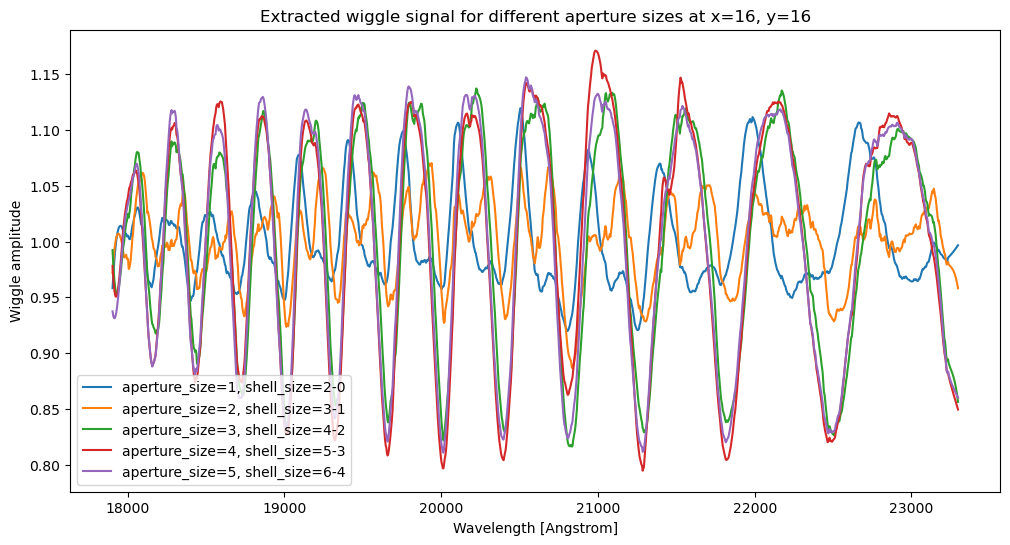

In [8]:
plt.rcParams["figure.figsize"] = (12, 6)

for s in np.arange(1, 6, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_signal(
        quasar_x,
        quasar_y,
        aperture_radius=s,
        annulus_outer_radius=s + 1,
        annulus_inner_radius=s - 1,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        label=f"aperture_size={s}, shell_size={s + 1}-{s - 1}",
    )

plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

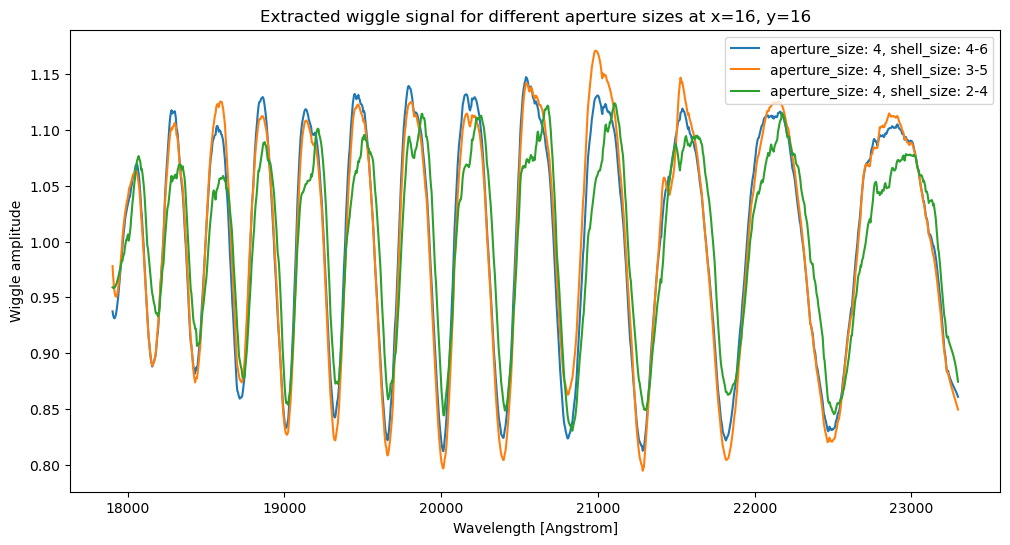

In [9]:
for i in range(0, 3, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_signal(
        quasar_x,
        quasar_y,
        aperture_radius=4,
        annulus_outer_radius=4 - i + 2,
        annulus_inner_radius=4 - i,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        # yerr=wiggle_noise,
        # marker="o",
        # markersize=2,
        # linestyle="None",
        label=f"aperture_size: {4}, shell_size: {4 - i}-{4 - i + 2}",
    )
plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

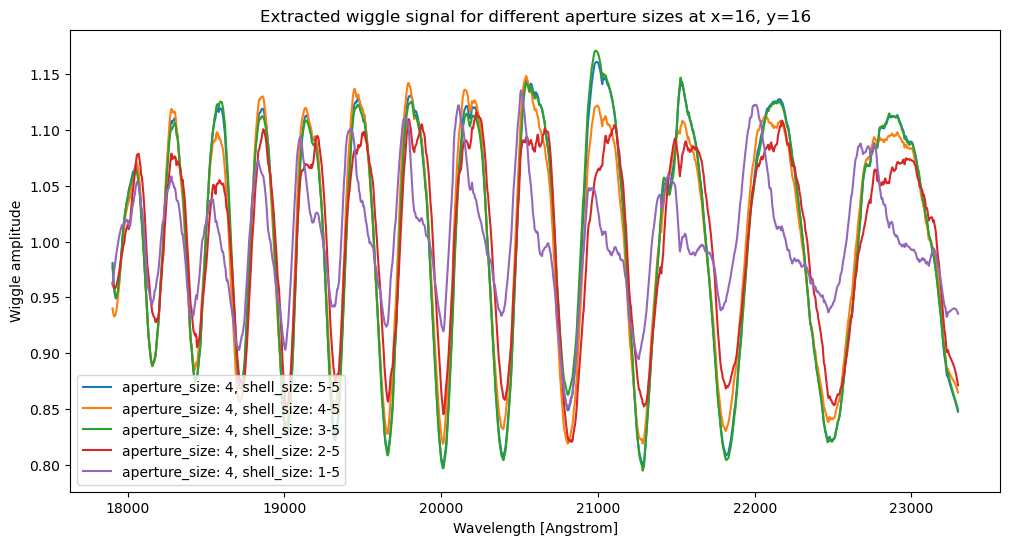

In [10]:
for i in range(0, 5, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_signal(
        quasar_x,
        quasar_y,
        aperture_radius=4,
        annulus_outer_radius=5,
        annulus_inner_radius=5 - i,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        # yerr=wiggle_noise,
        # marker="o",
        # markersize=2,
        # linestyle="None",
        label=f"aperture_size: {4}, shell_size: {5 - i}-{5}",
    )
plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

From the above tests, choosing `aperture_size = 4` and the annulus between 3 and 5 for the remainder of this demo, but you may want to experiment and tune for the best suitability for your data and use case.

In [11]:
aperture_radius = 4
annulus_outer_radius = 5
annulus_inner_radius = 3

## First look into how fitting of the wiggles looks like

Cost (from fitting extracted wiggle signal):  133628.3240572609


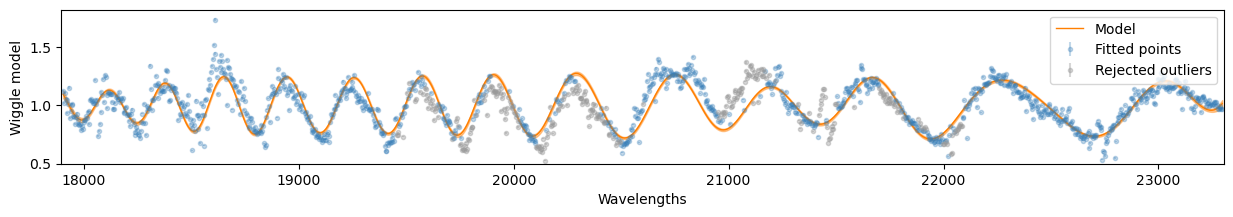

In [12]:
result_params = wcleaner.fit_wiggle(
    x=17,  # quasar_x,
    y=16,  # quasar_y,
    aperture_radius=aperture_radius,
    annulus_outer_radius=annulus_outer_radius,
    annulus_inner_radius=annulus_inner_radius,
    plot=True,
    n_amplitude=10,
    n_frequency=7,
    init_peak_detection_proximity_threshold=30,  # minimum distance between peaks/troughs to help avoid initial misidentification
    verbose=True,
    use_huber_loss=False,
    outlier_rejection_method="fdr",  # can alternatively use "sigma_clipping"
    fdr_alpha=0.05,  # FDR threshold for outlier rejection
    fdr_outlier_max_fraction=0.2,  # Maximum fraction of outliers allowed by FDR
    extract_covariance=True,
    fit_full_model=False,
    asymmetric_sharpening=False,
    symmetric_sharpening=False,
)

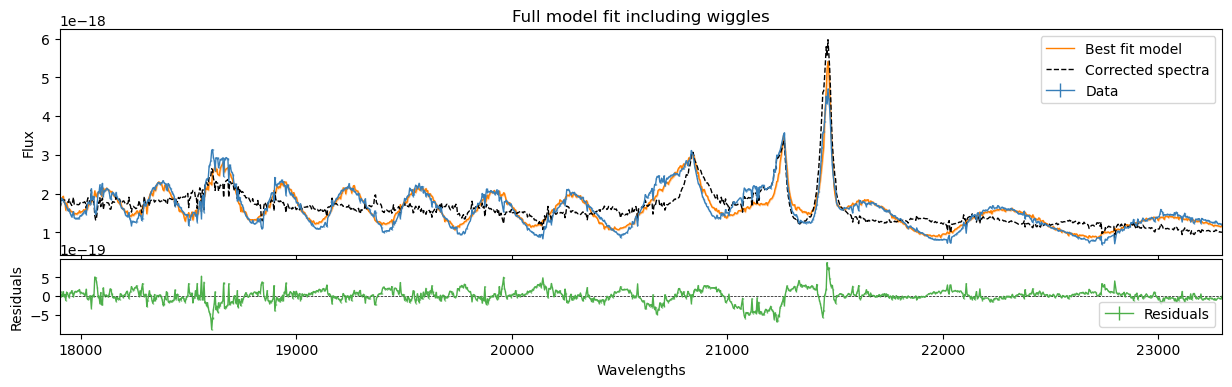

Cost (from fitting extracted wiggle signal):  130973.56808723169
Cost (from fitting full spectra):  95245.11617362275


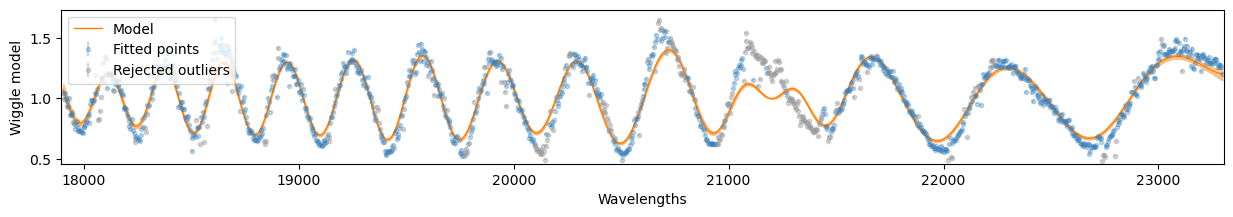

In [13]:
result_params = wcleaner.fit_wiggle(
    x=17,  # quasar_x,
    y=16,  # quasar_y,
    aperture_radius=5,
    annulus_outer_radius=annulus_outer_radius,
    annulus_inner_radius=annulus_inner_radius,
    plot=True,
    n_amplitude=10,
    n_frequency=10,
    init_peak_detection_proximity_threshold=30,  # minimum distance between peaks/troughs to help avoid initial misidentification
    verbose=True,
    use_huber_loss=False,
    outlier_rejection_method="fdr",  # can alternatively use "sigma_clipping"
    fdr_alpha=0.05,  # FDR threshold for outlier rejection
    fdr_outlier_max_fraction=0.2,  # Maximum fraction of outliers allowed by FDR
    extract_covariance=True,
    fit_full_model=True,
    asymmetric_sharpening=False,
    symmetric_sharpening=False,
)

We have to set the `asymmetric_sharpenning=True` in the `WiggleCleaner` initialization. The `symmetric_sharpening` is also set to `True` for sharper peaks than a sine function. These two options can be chosen individually, and you may experiment for the best settings suited for your use case.

The model for the modulation curve is:
$$
w(x) = 1 + A(x) \left[ \sin(\phi(x)) + k_1  \sin(\phi(x))^2 + k_2  \sin(3\phi(x))\right] + c(x)
$$

Here, $\sin(\phi(x))^2$ term creates the asymmetric sharpness, and the $\sin(3\phi(x))$ term creates the symmetric sharpness. The phase $\phi(x)$, amplitude $A(x)$ and continuum offset $c(x)$ are described with polynomials with orders `n_frequency`, `n_amplitude`, respectively.

## Using BIC to select the best combination of polynomial orders

Computing BIC for choices of n_amplitude and n_frequency...


  0%|          | 0/14 [00:00<?, ?it/s]

n_amplitude: 5, n_frequency: 2, bic: 12396.553459645918
n_amplitude: 6, n_frequency: 2, bic: 12316.118876521768
n_amplitude: 6, n_frequency: 3, bic: 12199.028628876313
n_amplitude: 6, n_frequency: 4, bic: 12138.487854977937


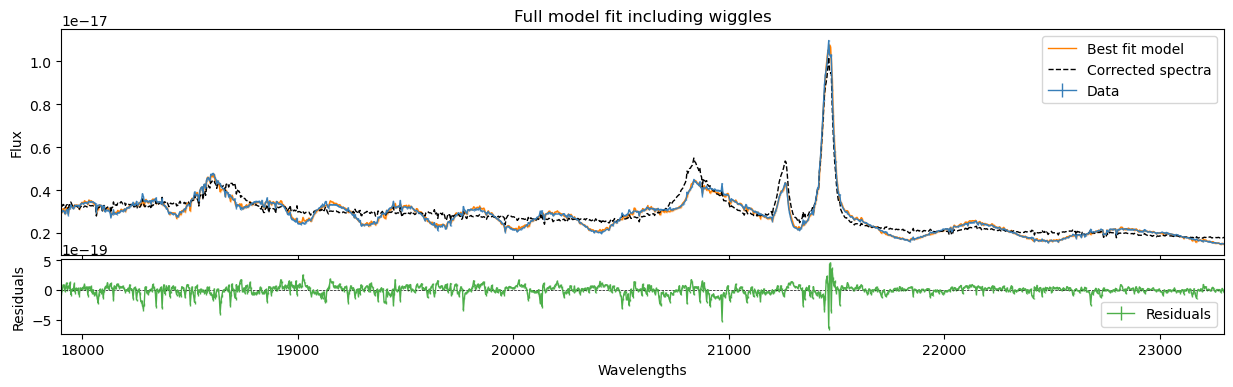

Cost (from fitting extracted wiggle signal):  12023.008760070792
Cost (from fitting full spectra):  7116.011485728051


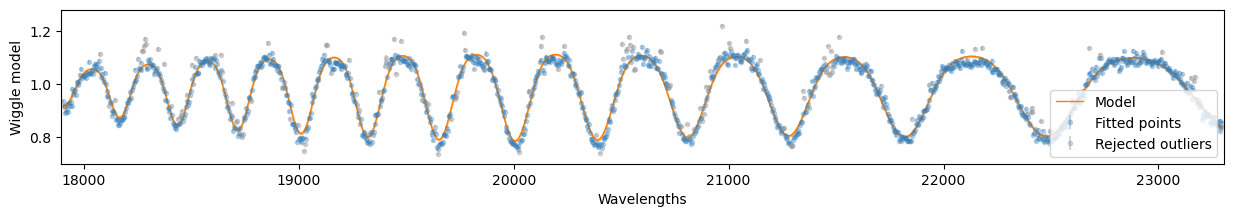

Best n_amplitude:  6
Best n_frequency:  4


(array([ 0.06347534,  0.11787569,  0.14050177,  0.17427643,  0.13908102,
         0.16072989,  0.14003121,  0.13993408, 53.51540999, 50.70187313,
        44.514529  , 36.18324039, 30.37981009, 27.81394013, 58.20408217,
        -0.31552992]),
 array([[ 5.19459448e-05, -2.78778175e-05,  1.45810382e-05,
         -6.47088558e-06,  3.57244408e-06, -3.04682707e-06,
          2.08379871e-06, -1.29069062e-06, -1.35126771e-04,
          9.13753304e-05, -1.07522863e-04,  5.83363059e-05,
         -1.75242551e-05,  1.28376415e-05, -3.17211645e-06,
          5.38306767e-07],
        [-2.78778175e-05,  5.55279320e-05, -3.49402428e-05,
          1.66146561e-05, -9.06843432e-06,  8.19425245e-06,
         -5.48098893e-06,  2.11950199e-06,  5.99168438e-05,
         -4.66301613e-05,  7.49008736e-05, -4.21419183e-05,
          1.17068028e-05, -1.27860745e-05,  2.95730084e-06,
          1.80134804e-06],
        [ 1.45810382e-05, -3.49402428e-05,  4.57583224e-05,
         -2.50042818e-05,  1.44004365e-05, -

In [14]:
wcleaner.fit_wiggle_with_model_selection(
    quasar_x,
    quasar_y,
    aperture_radius=aperture_radius,
    annulus_outer_radius=aperture_radius + 1,
    annulus_inner_radius=aperture_radius - 1,
    plot=True,
    n_amplitude=15,
    n_frequency=15,
    min_n_amplitude=5,
    min_n_frequency=2,
    selection_criteria="bic",
    init_peak_detection_proximity_threshold=200,
    outlier_rejection_method="fdr",
    use_huber_loss=False,
    fdr_alpha=0.01,
    fdr_outlier_max_fraction=0.10,
    extract_covariance=True,
    fit_full_model=True,
    asymmetric_sharpening=True,
    symmetric_sharpening=False,
)

## Finally, let `raccoon` clean your whole datacube. 🦝

You can setup a mask to restrict the region with spaxels to be cleaned.

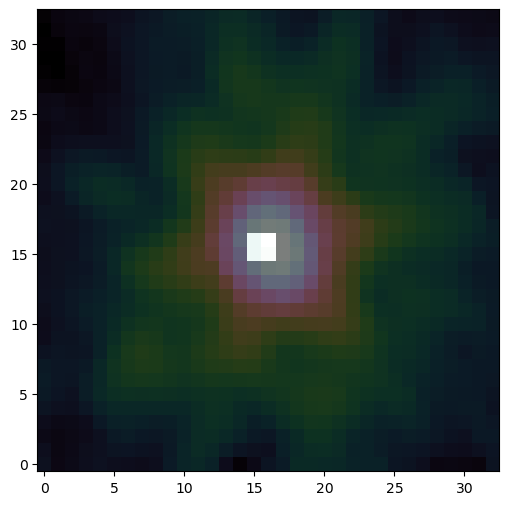

In [15]:
%matplotlib inline

mask = np.zeros_like(data_cube[0], dtype=bool)

center_x = quasar_x
center_y = quasar_y

mask[center_x - 1: center_x + 1, center_y - 1: center_y + 1] = True

plt.imshow(np.log10(np.nansum(data_cube, axis=0)), cmap="cubehelix", origin="lower")
plt.imshow(mask, alpha=0.5, cmap="cubehelix", origin="lower", vmin=0, vmax=1)
plt.show()

If `min_n_amplitude` and `min_n_frequency` are provided below, then the best combination according model selection (using BIC or $\chi^2$) will be used. But, it will be taking longer since the fitting is going through all the combinations within the given range.

Cleaning spaxels:   0%|          | 0/4 [00:00<?, ?it/s]

###########################
Fitting spaxel: 15, 15
Cost (from fitting extracted wiggle signal):  18966.171840116895
Wiggle detection sigma: 6.65
Model variance: 0.0529, residual variance: 0.0355, ratio: 1.4902
Wiggle detected. Cleaning spaxel: 15, 15.


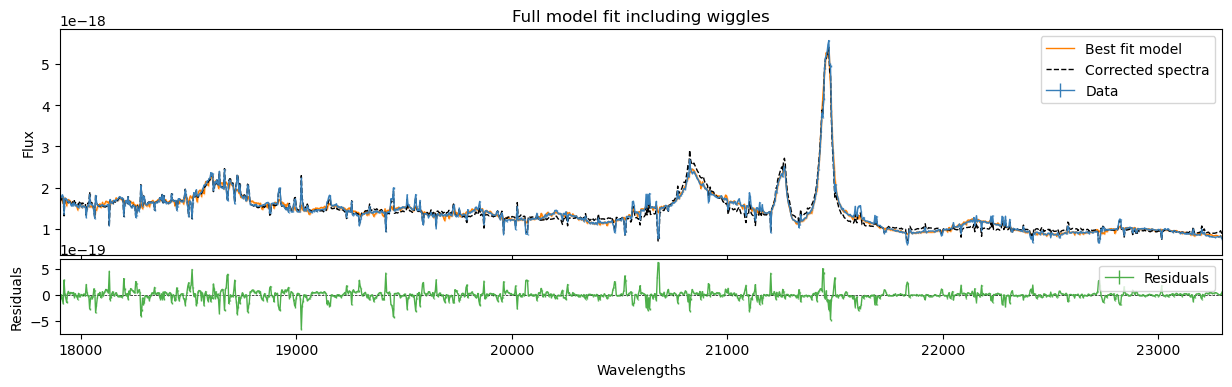

Cost (from fitting extracted wiggle signal):  14414.223597950337
Cost (from fitting full spectra):  11503.724089915795


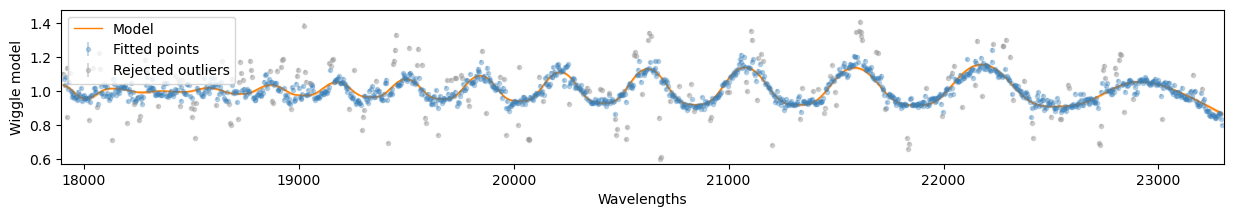

###########################
Fitting spaxel: 15, 16
Cost (from fitting extracted wiggle signal):  7096.600638720474
Wiggle detection sigma: 9.50
Model variance: 0.0708, residual variance: 0.0184, ratio: 3.8381
Wiggle detected. Cleaning spaxel: 15, 16.


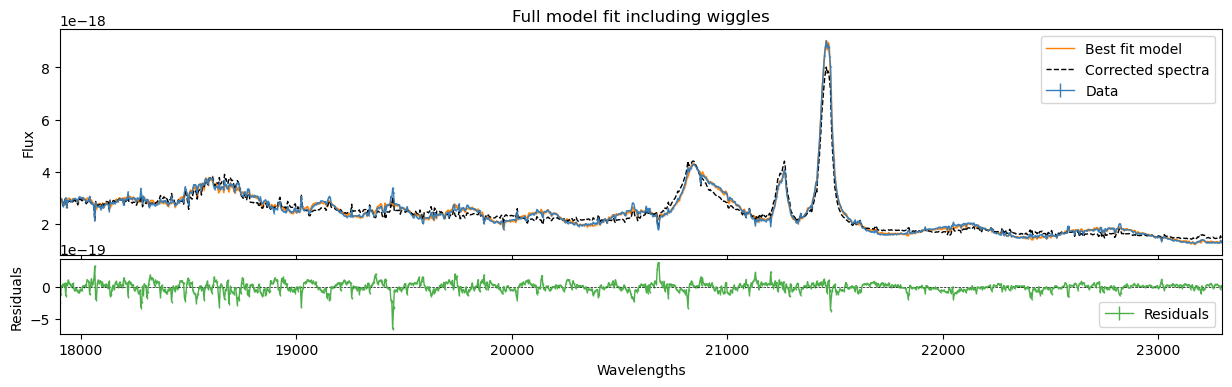

Cost (from fitting extracted wiggle signal):  12907.566278205537
Cost (from fitting full spectra):  8078.934032942863


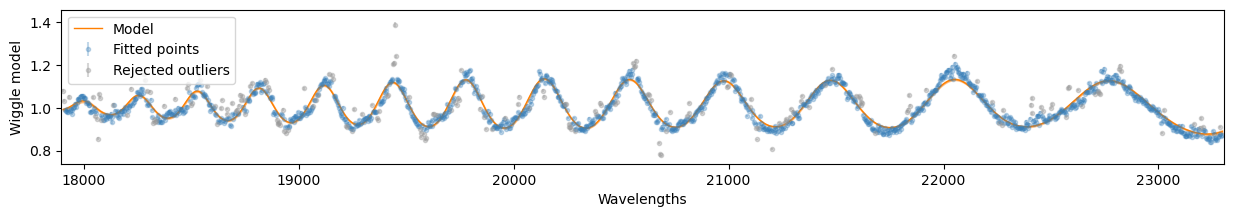

###########################
Fitting spaxel: 16, 15
Cost (from fitting extracted wiggle signal):  31580.101031417402
Wiggle detection sigma: 12.96
Model variance: 0.1023, residual variance: 0.0443, ratio: 2.3104
Wiggle detected. Cleaning spaxel: 16, 15.


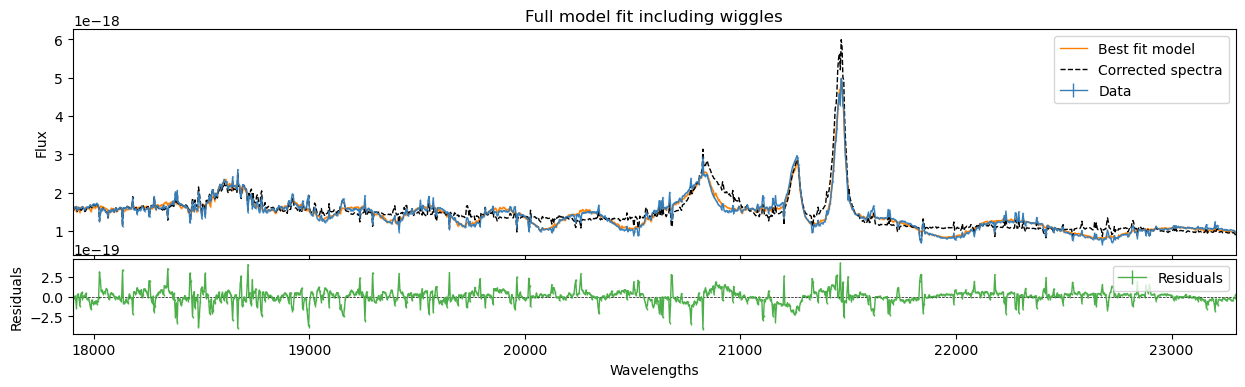

Cost (from fitting extracted wiggle signal):  24109.45335886724
Cost (from fitting full spectra):  19087.060194739068


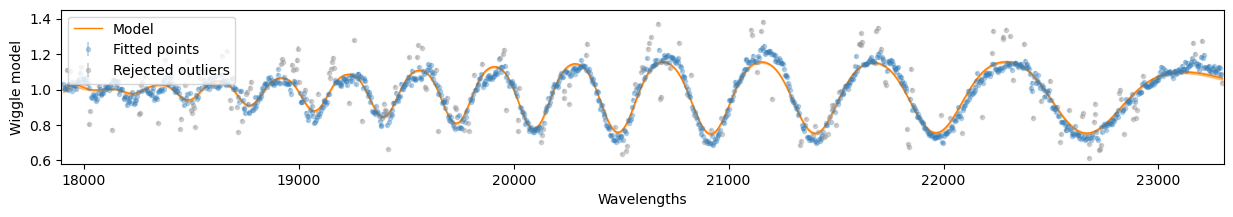

###########################
Fitting spaxel: 16, 16
Cost (from fitting extracted wiggle signal):  5930.737632027807
Wiggle detection sigma: 15.00
Model variance: 0.1020, residual variance: 0.0168, ratio: 6.0849
Wiggle detected. Cleaning spaxel: 16, 16.


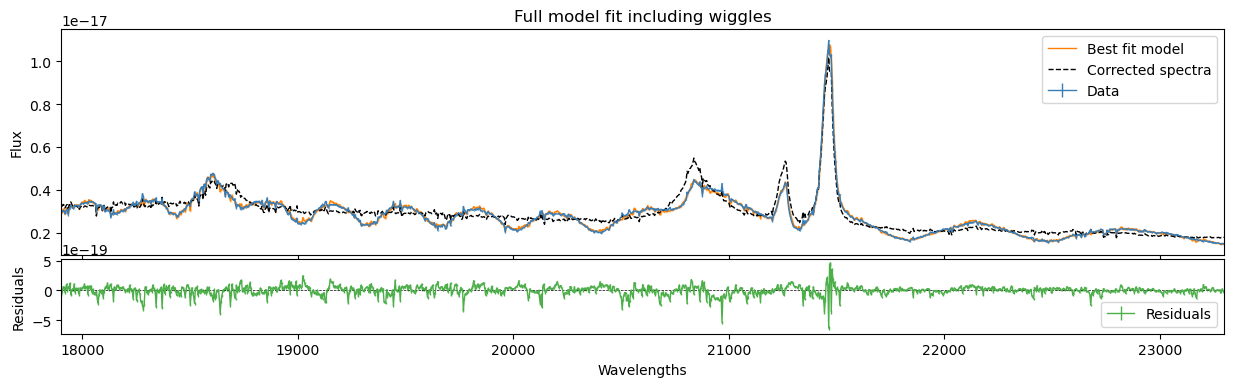

Cost (from fitting extracted wiggle signal):  9810.09406860546
Cost (from fitting full spectra):  5831.209641297588


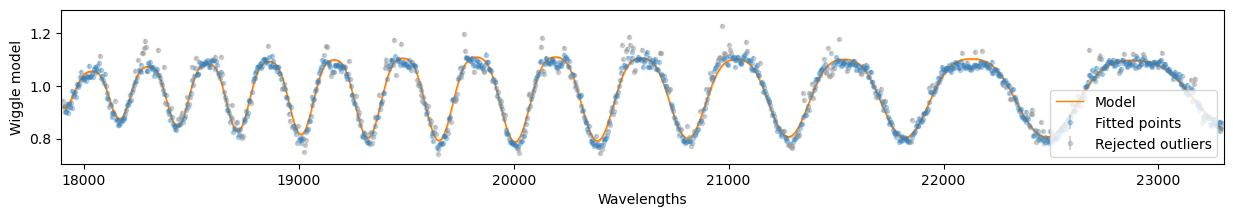

Cleaning done!


In [16]:
cleaned_cube, cleaned_noise_cube, cleaned_map = wcleaner.clean_cube(
    wiggle_detection_sigma_threshold=5.0,
    wiggle_detection_variance_ratio_threshold=0.2,
    n_amplitude=6,
    n_frequency=4,
    fit_full_model=True,
    min_n_amplitude=None,
    min_n_frequency=None,
    cleaning_mask=mask,
    init_peak_detection_proximity_threshold=200,
    aperture_radius=aperture_radius,
    annulus_outer_radius=annulus_outer_radius,
    annulus_inner_radius=annulus_inner_radius,
    plot=True,
    verbose=True,
    extract_uncertainty=True,
    outlier_rejection_method="fdr",
    use_huber_loss=False,
    fdr_alpha=0.01,
    fdr_outlier_max_fraction=0.15,
    sigma_clip_sigma=3,
    sigma_clip_max_iterations=20,
    num_samples_uncertainty_region=1000,
    symmetric_sharpening=True,
    asymmetric_sharpening=True,
)

plt.show()

### Let's see which spaxels were cleaned in the end, by having a wiggle signal detected above the chosen threshold.

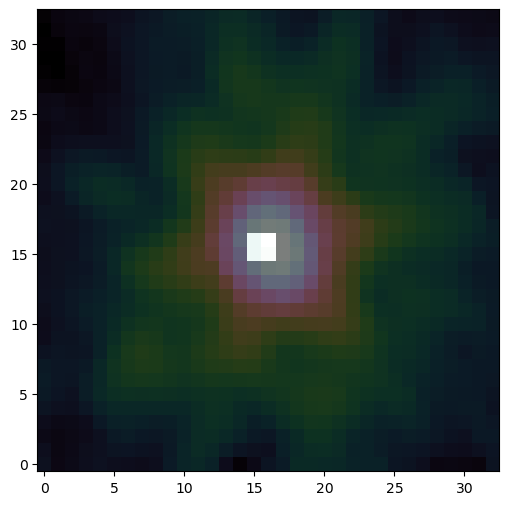

In [17]:
%matplotlib inline

plt.imshow(
    np.log10(np.nansum(data_cube, axis=0)),
    cmap="cubehelix",
    origin="lower",
)
plt.imshow(cleaned_map, alpha=0.5, cmap="cubehelix", origin="lower", vmin=0, vmax=1)
plt.show()

## Save the cleaned cube if everything looks fine!

In [18]:
# output_file_path = ...
# with fits.open(datacube_file) as hdu:
#     hdu["SCI"].data = cleaned_cube
#     hdu["ERR"].data = cleaned_noise_cube

#     hdu.writeto(
#         output_file_path,
#     )